# Application to one case

This notebook walks through a complete attribution workflow for a single Tropical Cyclone (TC) case using the `tc_track_analogues` package.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
from glob import glob
import pickle as pkl
from tqdm import tqdm
import os
import huracanpy

from scipy.stats import ttest_ind, cramervonmises_2samp

import tc_track_analogues as tca

## Colors
color_full = 'k'
color_cf = sns.color_palette("tab20")[0] # Blue
color_f = sns.color_palette("tab20")[2] # Orange
pal = {"CF":color_cf, "F": color_f}

## 1. Define the target

In [2]:
NAME, SEASON, BASIN = "MELISSA", 2025, "NA"
LANDFALL_TIME = "2025-10-28T18:00:00"
TIME_WINDOW = 24 # in hours

/Users/sbourdin/miniforge3/envs/tc-track-analogues/lib/python3.14/site-packages/huracanpy/_data/_csv.py:65: DtypeWarning: Columns (61,66,77) have mixed types. Specify dtype option on import or set low_memory=False.
  tracks = load_function(filename, **kwargs)


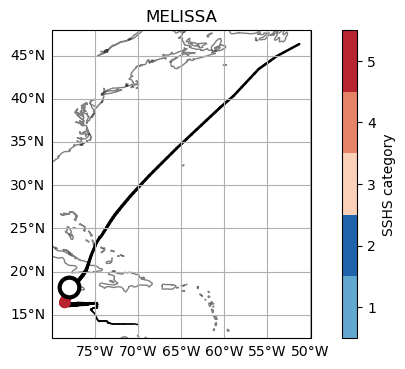

In [3]:
# Identify target case's track in IBTrACS
target = tca.load_target_track_hourly(NAME, SEASON, BASIN)
landfall = target.sel(time = LANDFALL_TIME)
target_window = tca.extract_target_window_before_landfall(
                                        target, LANDFALL_TIME, TIME_WINDOW
                                        )
# Visualise the target
tca.plot_target_case(target, target_window, landfall, NAME)

## 2. Define the catalogues

In [4]:
catalogues = {
    "IBTrACS":tca.load_ibtracs_catalogue(BASIN, update = False),
    "CHAZ":tca.load_CHAZ_catalogue(),
    "MIT":tca.load_MIT_catalogue(),
    "SEAS520C":tca.load_SEAS520C_catalogue(),
}

/Users/sbourdin/miniforge3/envs/tc-track-analogues/lib/python3.14/site-packages/huracanpy/_data/_csv.py:65: DtypeWarning: Columns (21,139,159) have mixed types. Specify dtype option on import or set low_memory=False.
  tracks = load_function(filename, **kwargs)
/Users/sbourdin/miniforge3/envs/tc-track-analogues/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
## Parameters associated to the catalogues
parameters = pd.DataFrame({
    "index":['IBTrACS', 'CHAZ', 'MIT', 'SEAS520C'],
    "intensity_cols": # Intensity parameters available 
        [['wind', 'pres'], 
         ['wind'], 
         ['wind'],
         ['wind', 'pres']],
    "dates": # Period boundaries
        [[1950, 1984, 1985, 2019], 
         [1950, 1984, 1985, 2019], 
         [1950, 1984, 1985, 2019], 
         [1901, 1955, 1956, 2010], 
        ],
    "exclusion_dist": # Distance beyond which a point is not considered at all
        [1000, 300, 300, 300],
    "d_max": # Maximum analogue distance 
        [3.,1., 1., 1.5]
}).set_index("index")

## 3. Compute analogues

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:07<00:00,  1.85s/it]


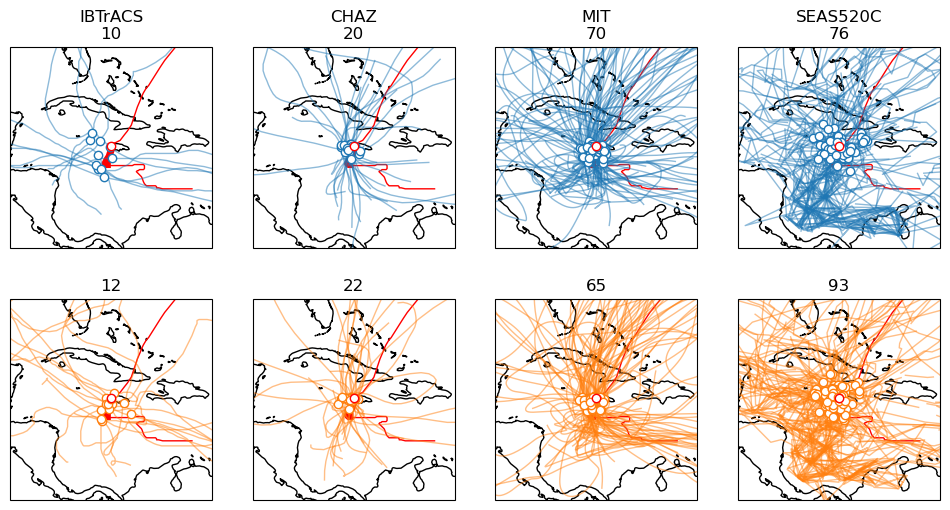

In [6]:
# Compute distance to target event
for c in tqdm(catalogues):
    catalogues[c]["dist2target"] = tca.add_dist_from_target_landfall(catalogues[c], landfall.lon.values, landfall.lat.values)
# Compute analogues
analogues = {c: tca.find_analogues(target_window, catalogues[c], exclusion_dist = parameters.exclusion_dist.loc[c], d_max = parameters.d_max.loc[c]) for c in tqdm(catalogues)}
# Separate between factual and counter-factual
analogues = tca.flag_periods(analogues, parameters)
# Visualise
tca.plot_analogues(analogues, catalogues, target, target_window, landfall, color_cf, color_f)

## 4. Analyse differences between periods' analogues

In [7]:
# Compute statistics
mean = {}
cis = {}
CvM_pval = {}
for c in catalogues:
    wind_name = [v for v in list(catalogues[c].variables.keys()) if "wind" in v][0]
    means = analogues[c].groupby("period")[wind_name].mean()
    ci = ttest_ind(analogues[c][analogues[c].period == "F"][wind_name], analogues[c][analogues[c].period == "CF"][wind_name]).confidence_interval()
    mean[c] = means.loc['F'] - means.loc['CF']
    cis[c] = [ci.low, ci.high]
    CvM_pval[c] = cramervonmises_2samp(analogues[c][analogues[c].period == "F"][wind_name], analogues[c][analogues[c].period == "CF"][wind_name]).pvalue

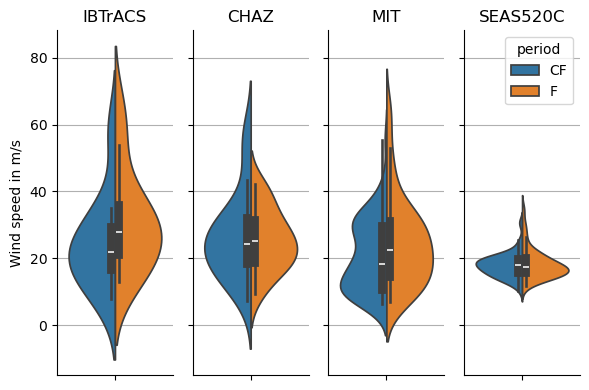

In [9]:
fig, axs = plt.subplots(1, 4, figsize = [6,4], sharey = True)
for i, c in enumerate(analogues):
    wind_name = [v for v in list(catalogues[c].variables.keys()) if "wind" in v][0]
    sns.violinplot(data = analogues[c][analogues[c].period.isin(["F", "CF"])], y = wind_name, hue = "period", split = True, ax = axs[i], hue_order = ["CF", "F"], legend = i == 3)
    axs[i].set_title(c) # + '\nCvM p-val ' + str(np.round(CvM_pval[c], 2)))
    axs[i].grid(axis = 'y')
    axs[i].set_axisbelow(True)
axs[0].set_ylabel("Wind speed in m/s")

sns.despine()

plt.tight_layout()

In [11]:
mean, cis

({'IBTrACS': np.float64(6.4705828554705),
  'CHAZ': np.float64(-1.383341003512708),
  'MIT': np.float64(4.073497714786985),
  'SEAS520C': np.float32(0.41968155)},
 {'IBTrACS': [np.float64(-6.848405919046943), np.float64(19.789571629987943)],
  'CHAZ': [np.float64(-8.39369803782101), np.float64(5.627016030795595)],
  'MIT': [np.float64(-0.07351964623117357), np.float64(8.22051507580515)],
  'SEAS520C': [np.float32(nan), np.float32(nan)]})

<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/48/8b8fx99d43s9q28c02l02ty40000gp/T/ipykernel_9034/2173453936.py:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel("$\Delta u$ in m/s")


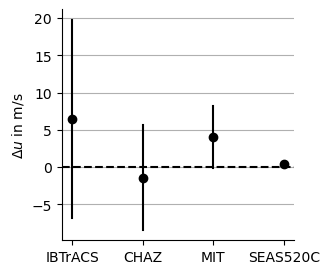

In [12]:
plt.figure(figsize = (3,3))
plt.scatter(mean.keys(), mean.values(), zorder = 10, color = 'k')
for i, c in enumerate(catalogues):
    plt.plot([i,i], list(cis.values())[i], color = 'k')
plt.axhline(y=0, color = 'k', linestyle = "--")
plt.ylabel("$\Delta u$ in m/s")
plt.grid(axis = 'y')
sns.despine()